In [1]:
import os
import numpy as np
import glob
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import tensorflow as tf

In [2]:
today = datetime.date.today()
date = today.strftime("%B%d")
date

'January14'

In [3]:
# Gather data
data = []
log_path = os.path.join('.', 'logs', 'January10_13', '*', '*')
logs = glob.glob(log_path)
for log in logs:
    if "events.out.tfevents" in log:
        experiment_info = log.split(os.sep)[-2].split('_')
        algorithm = experiment_info[0]
        st = experiment_info[1]
        # print(log)
        print(log.split(os.sep))
        print(experiment_info)
        
        for e in tf.compat.v1.train.summary_iterator(log):
            for v in e.summary.value:
                if v.tag == 'rollout/ep_rew_mean':
                    data.append({
                        'algorithm': algorithm,
                        'set': st,
                        'step': e.step,
                        'reward': v.simple_value
                    })
    else:
        print(f"Not a tensorflow log file, file: {log}")
df = pd.DataFrame(data)
# df.to_csv(rf"results\wheeled_default_raw_{date}.csv")
df

['.', 'logs', 'January10_13', 'a2c_env1', 'events.out.tfevents.1768071840.kaos5-1.35168.0']
['a2c', 'env1']

Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`
Not a tensorflow log file, file: .\logs\January10_13\a2c_env1\log.txt
Not a tensorflow log file, file: .\logs\January10_13\a2c_env1\progress.csv
Not a tensorflow log file, file: .\logs\January10_13\a2c_env1\progress.json
['.', 'logs', 'January10_13', 'a2c_env10', 'events.out.tfevents.1768094254.kaos5-1.35168.9']
['a2c', 'env10']
Not a tensorflow log file, file: .\logs\January10_13\a2c_env10\log.txt
Not a tensorflow log file, file: .\logs\January10_13\a2c_env10\progress.csv
Not a tensorflow log file, file: .\logs\January10_13\a2c_env10\progress.json
['.', 'logs', 'January10_13', 'a2c_env2', 'events.out.tfevents.1768074234.kaos5-1.35168.1']
['a2c', 'env2']
Not a tensorflow log file, file: .\logs\January10_13\a2c_env2\log.txt
Not a tensorflow log file, file: .\logs\January10_13\a2c_env2\progress.cs

,algorithm,set,step,reward
0,a2c,env1,2000,-313326.343750
1,a2c,env1,4000,-282777.562500
2,a2c,env1,6000,-280570.468750
3,a2c,env1,8000,-215452.937500
4,a2c,env1,10000,-170490.515625
...,...,...,...,...
270633,trpo,env9,974848,-36685.726562
270634,trpo,env9,983040,-33262.394531
270635,trpo,env9,991232,-30930.578125
270636,trpo,env9,999424,-30603.308594


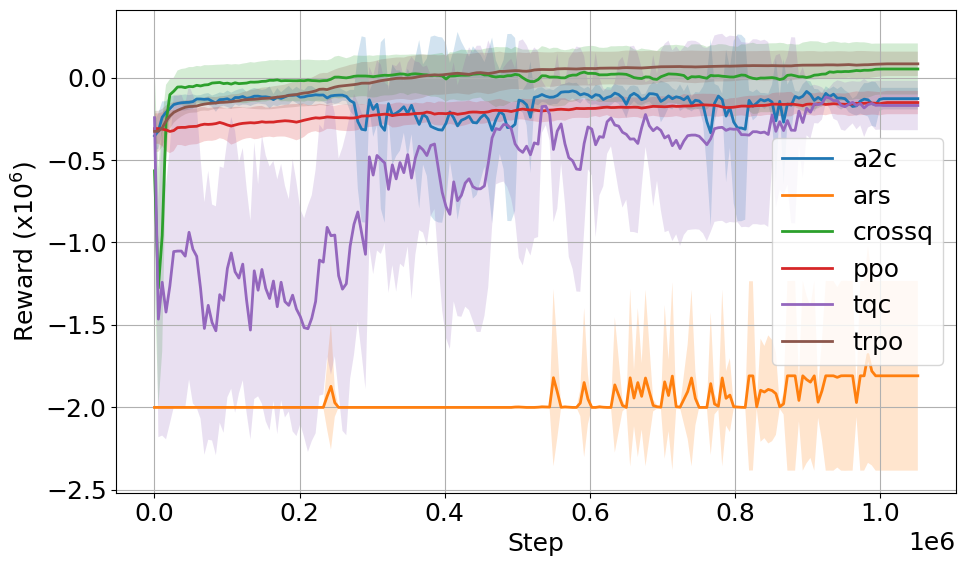

In [4]:
# Scaling the rewards for visualization
df['reward_scaled'] = df['reward'] / 1000000
df['reward_scaled'] = df['reward_scaled'].clip(lower=-2)

# Define a common x-axis (based on min-max steps across all algorithms)
min_step = df['step'].min()
max_step = df['step'].max()
common_steps = np.linspace(min_step, max_step, 200)

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10,6))

# Group by algorithm
for algo, algo_df in df.groupby('algorithm'):
    runs = []

    # For each run (set), interpolate rewards to common steps
    for run_id, run_df in algo_df.groupby('set'):
        x = run_df['step'].values
        y = run_df['reward_scaled'].values
        interp_rewards = np.interp(common_steps, x, y)
        runs.append(interp_rewards)

    runs = np.array(runs)
    mean_rewards = runs.mean(axis=0)
    std_rewards = runs.std(axis=0)

    # Plot with variance shading
    plt.plot(common_steps, mean_rewards, label=algo, linewidth=2)
    plt.fill_between(common_steps, mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.2)

plt.xlabel("Step")
plt.ylabel("Reward (x$10^6$)")
# plt.title("RL Algorithms Reward Curves with Variance")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(rf"plots/wheeled_default_{date}.png")
plt.show()

In [5]:
a2c_df = df[df['algorithm']=='a2c']
ppo_df = df[df['algorithm']=='ppo']
trpo_df = df[df['algorithm']=='trpo']
ars_df = df[df['algorithm']=='ars']
crossq_df = df[df['algorithm']=='crossq']
tqc_df = df[df['algorithm']=='tqc']


a2c_data = {"Setting": "AB", 
            "Algorithm": "A2C", 
            "Mean": a2c_df['reward'].mean(),
            "SD": a2c_df['reward'].std(),
            "Max": a2c_df['reward'].max(),
            "Range": (a2c_df['reward'].max() - a2c_df['reward'].min())}
ppo_data = {"Setting": "AB", 
            "Algorithm": "PPO", 
            "Mean": ppo_df['reward'].mean(),
            "SD": ppo_df['reward'].std(),
            "Max": ppo_df['reward'].max(),
            "Range": (ppo_df['reward'].max() - ppo_df['reward'].min())}
trpo_data = {"Setting": "AB", 
            "Algorithm": "TRPO", 
            "Mean": trpo_df['reward'].mean(),
            "SD": trpo_df['reward'].std(),
            "Max": trpo_df['reward'].max(),
            "Range": (trpo_df['reward'].max() - trpo_df['reward'].min())}
ars_data = {"Setting": "AB", 
            "Algorithm": "ARS", 
            "Mean": ars_df['reward'].mean(),
            "SD": ars_df['reward'].std(),
            "Max": ars_df['reward'].max(),
            "Range": (ars_df['reward'].max() - ars_df['reward'].min())}
crossq_data = {"Setting": "AB", 
            "Algorithm": "CrossQ", 
            "Mean": crossq_df['reward'].mean(),
            "SD": crossq_df['reward'].std(),
            "Max": crossq_df['reward'].max(),
            "Range": (crossq_df['reward'].max() - crossq_df['reward'].min())}
tqc_data = {"Setting": "AB", 
            "Algorithm": "TQC", 
            "Mean": tqc_df['reward'].mean(),
            "SD": tqc_df['reward'].std(),
            "Max": tqc_df['reward'].max(),
            "Range": (tqc_df['reward'].max() - tqc_df['reward'].min())}


set_tab_df = pd.DataFrame([a2c_data, ppo_data, trpo_data, ars_data, crossq_data, tqc_data])
set_tab_df

,Setting,Algorithm,Mean,SD,Max,Range
0,AB,A2C,-1.721467e+05,3.276215e+05,72505.773438,5.663425e+06
1,AB,PPO,-2.105497e+05,8.530069e+04,52833.023438,7.083018e+05
2,AB,TRPO,2.593566e+03,1.318480e+05,133784.593750,7.473905e+05
3,AB,ARS,-9.591694e+06,1.043522e+07,-73451.187500,2.996149e+07
4,AB,CrossQ,1.128131e+05,1.221617e+05,133790.000000,6.185034e+06
5,AB,TQC,-2.249849e+05,6.402688e+05,-41472.609375,1.504851e+07


In [6]:
set_tab_df_sc = set_tab_df.select_dtypes(include='number') / 1000000
set_tab_df_sc.insert(0, 'Setting', set_tab_df['Setting'])
set_tab_df_sc.insert(1, 'Algorithm', set_tab_df['Algorithm'])
set_tab_df_sc

,Setting,Algorithm,Mean,SD,Max,Range
0,AB,A2C,-0.172147,0.327621,0.072506,5.663425
1,AB,PPO,-0.210550,0.085301,0.052833,0.708302
2,AB,TRPO,0.002594,0.131848,0.133785,0.747390
3,AB,ARS,-9.591694,10.435219,-0.073451,29.961495
4,AB,CrossQ,0.112813,0.122162,0.133790,6.185034
5,AB,TQC,-0.224985,0.640269,-0.041473,15.048505
